In [3]:
import pandas as pd
import numpyro
import jax
import jax.numpy as jnp
from jax import random
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro import sample
import matplotlib.pyplot as plt
# load the data 
df = pd.read_csv('/Users/yhra/Documents/Master/Semester_3/BATIP/Supernova_project/Data/Pantheon+SH0ES.dat', sep='\s+', header=0)


# get the data
z = df['zCMB'].values
mu_obs = df['m_b_corr'].values
mu_err = df['MU_SH0ES_ERR_DIAG'].values

df.columns

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')

In [140]:
c = 299792.458 # km/s

def H0(H0, Om, Ok, z):
    """Hubble parameter at redshift z"""
    return H0 * jnp.sqrt(Om * (1 + z)**3 + Ok * (1 + z)**2 + (1 - Om - Ok))

def chi(h0, Om, Ok, z):
    """Comoving distance in Mpc"""
    # For scalar z
    if jnp.isscalar(z):
        # Avoid z=0 in integration
        z_array = jnp.linspace(0.001, jnp.maximum(z, 0.001), 1000)
        # Add small constant to denominator to prevent division by zero
        integrand = c / (H0(h0, Om, Ok, z_array) + 1e-10)
        return jax.scipy.integrate.trapezoid(integrand, z_array)
    # For array z
    else:
        return jax.vmap(lambda x: chi(h0, Om, Ok, x))(z)

def luminosity_distance(H0, Om, Ok, z):
    """Luminosity distance in Mpc"""
    chi_val = chi(H0, Om, Ok, z)
    
    # Flat universe (Ok = 0)
    flat_case = chi_val
    # Open universe (Ok > 0)
    open_case = 1/jnp.sqrt(Ok) * jnp.sinh(jnp.sqrt(Ok) * chi_val)
    # Closed universe (Ok < 0)
    closed_case = 1/jnp.sqrt(jnp.abs(Ok)) * jnp.sin(jnp.sqrt(jnp.abs(Ok)) * chi_val)
    
    # First check if Ok = 0
    r_z = jnp.where(Ok == 0, flat_case,
                    # Then check if Ok > 0
                    jnp.where(Ok > 0, open_case, closed_case))
    
    return r_z * (1 + z)

def distance_modulus(H0, Om, Ok, z):
    """Distance modulus in magnitudes"""
    d_L = luminosity_distance(H0, Om, Ok, z)
    # Add small constant to prevent log(0)
    return 5 * jnp.log10(d_L + 1e-10)  # Removed the +25 offset



In [141]:
def test_cosmology_functions(z_test=1.0, H0_test=70.0, Om_test=0.3, Ok_test=0.0):
    """Test each cosmological function with given parameters"""
    print("Testing with parameters:", 
          f"z={z_test}, H0={H0_test}, Om={Om_test}, Ok={Ok_test}")
    
    # Test H0 function
    h = H0(H0_test, Om_test, Ok_test, z_test)
    print(f"H(z) = {h}")
    
    # Test chi function
    chi_val = chi(H0_test, Om_test, Ok_test, z_test)
    print(f"chi = {chi_val}")
    
    # Test luminosity distance
    d_L = luminosity_distance(H0_test, Om_test, Ok_test, z_test)
    print(f"d_L = {d_L}")
    
    # Test distance modulus
    mu = distance_modulus(H0_test, Om_test, Ok_test, z_test)
    print(f"mu = {mu}")
    
    # Convert values to JAX array before checking
    values = jnp.array([h, chi_val, d_L, mu])
    return not (jnp.any(jnp.isnan(values)) or jnp.any(jnp.isinf(values)))

# Test with a single value
print("Single value test:")
test_cosmology_functions()

# Test with an array
print("\nArray test:")
z_array = jnp.array([0.1, 0.5, 1.0, 2.0])
test_cosmology_functions(z_test=z_array)

# Test with extreme values
print("\nExtreme value test:")
test_cosmology_functions(z_test=0.001)

Single value test:
Testing with parameters: z=1.0, H0=70.0, Om=0.3, Ok=0.0
H(z) = 123.24771118164062
chi = 3299.54736328125
d_L = 6599.0947265625
mu = 19.09741973876953

Array test:
Testing with parameters: z=[0.1 0.5 1.  2. ], H0=70.0, Om=0.3, Ok=0.0
H(z) = [ 73.39326  91.60377 123.24772 207.65356]
chi = [ 414.17273 1884.3438  3299.5474  5175.581  ]
d_L = [  455.59003  2826.5156   6599.0947  15526.743  ]
mu = [13.29287  17.256256 19.09742  20.9554  ]

Extreme value test:
Testing with parameters: z=0.001, H0=70.0, Om=0.3, Ok=0.0
H(z) = 70.03152465820312
chi = 0.0
d_L = 0.0
mu = -49.999996185302734


True

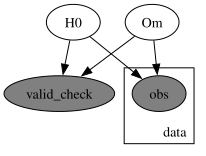

In [142]:
rng_key = random.PRNGKey(0)
def model(z: jnp.array, mu_obs: jnp.array, mu_err: jnp.array):
    """Model for numpyro inference"""
    # draw from prior
    H0 = sample("H0", dist.TruncatedNormal(70.0, 5.0, low=50.0, high=90.0))
    Om = sample("Om", dist.TruncatedNormal(0.3, 0.1, low=0.1, high=0.9))
    Ok = 0.0  # Fix Ok=0 for flat universe
    
    # calculate expected distance modulus
    mu_exp = distance_modulus(H0, Om, Ok, z)
    
    # Add check for invalid values
    is_valid = ~(jnp.isnan(mu_exp) | jnp.isinf(mu_exp))
    numpyro.factor("valid_check", jnp.where(is_valid, 0., -jnp.inf))
    
    # sample observations
    with numpyro.plate("data", len(z)):
        sample("obs", dist.Normal(mu_exp, mu_err), obs=mu_obs)

# visualize the model architecture
numpyro.render_model(model, model_args=(z, mu_obs, mu_err))


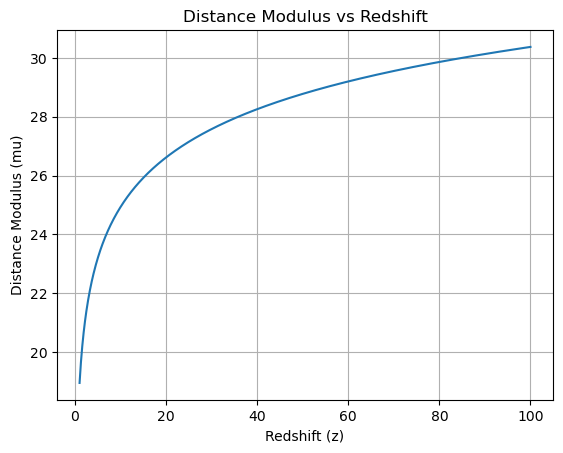

Test successful if no NaN or inf values: True

Actual Data Statistics:
Number of data points: 1701
z range: [0.001, 2.261]
mu_obs range: [9.746, 26.930]
mu_err range: [0.115, 1.517]

Data Quality Checks:
NaN in z: False
NaN in mu_obs: False
NaN in mu_err: False
inf in z: False
inf in mu_obs: False
inf in mu_err: False

Model Prediction Checks:
NaN in predictions: False
inf in predictions: False


In [143]:
# Test the model
z_test = jnp.linspace(1, 100, 1000)  # avoid z=0
H0_test = 75.0
Om_test = 0.3
Ok_test = 0.0

# Generate test data
mu_test = distance_modulus(H0_test, Om_test, Ok_test, z_test)
# plot the test data
plt.plot(z_test, mu_test)
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (mu)')
plt.title('Distance Modulus vs Redshift')
plt.grid()
plt.show()
print("Test successful if no NaN or inf values:", 
      jnp.all(~jnp.isnan(mu_test)) and jnp.all(~jnp.isinf(mu_test)))

# Now let's examine your actual data
print("\nActual Data Statistics:")
print(f"Number of data points: {len(z)}")
print(f"z range: [{z.min():.3f}, {z.max():.3f}]")
print(f"mu_obs range: [{mu_obs.min():.3f}, {mu_obs.max():.3f}]")
print(f"mu_err range: [{mu_err.min():.3f}, {mu_err.max():.3f}]")

# Test if any of the actual data contains NaN or inf
print("\nData Quality Checks:")
print("NaN in z:", jnp.any(jnp.isnan(z)))
print("NaN in mu_obs:", jnp.any(jnp.isnan(mu_obs)))
print("NaN in mu_err:", jnp.any(jnp.isnan(mu_err)))
print("inf in z:", jnp.any(jnp.isinf(z)))
print("inf in mu_obs:", jnp.any(jnp.isinf(mu_obs)))
print("inf in mu_err:", jnp.any(jnp.isinf(mu_err)))

# Try calculating model predictions for the actual data points
mu_pred = distance_modulus(70.0, 0.3, 0.0, z)
print("\nModel Prediction Checks:")
print("NaN in predictions:", jnp.any(jnp.isnan(mu_pred)))
print("inf in predictions:", jnp.any(jnp.isinf(mu_pred)))

### Set up the inference

In [144]:
# 1. First, let's test each component separately with the first data point
z_test = z[0]
print(f"Testing with z = {z_test}")

# Test H0 calculation
h_test = H0(70.0, 0.3, 0.0, z_test)
print(f"H(z) = {h_test}")

# Test chi calculation
try:
    chi_test = chi(70.0, 0.3, 0.0, z_test)
    print(f"chi = {chi_test}")
except Exception as e:
    print("Error in chi calculation:", str(e))

# Test luminosity distance
try:
    d_L_test = luminosity_distance(70.0, 0.3, 0.0, z_test)
    print(f"d_L = {d_L_test}")
except Exception as e:
    print("Error in luminosity distance calculation:", str(e))

# Test distance modulus
try:
    mu_test = distance_modulus(70.0, 0.3, 0.0, z_test)
    print(f"mu = {mu_test}")
except Exception as e:
    print("Error in distance modulus calculation:", str(e))

# 2. Let's try a super simple model without any JAX transformations
def basic_model(z_val, mu_obs_val, mu_err_val):
    """Basic model without JAX transformations"""
    # Fixed parameters
    H0_val = 70.0
    Om_val = 0.3
    Ok_val = 0.0
    
    # Calculate mu_exp directly
    mu_exp_val = distance_modulus(H0_val, Om_val, Ok_val, z_val)
    print(f"Calculated mu_exp = {mu_exp_val}")
    
    # Calculate log likelihood manually
    log_like = -0.5 * ((mu_obs_val - mu_exp_val) / mu_err_val) ** 2
    print(f"Log likelihood = {log_like}")
    
    return mu_exp_val, log_like

# Test the basic model with the first data point
print("\nTesting basic model:")
try:
    mu_exp_test, log_like_test = basic_model(z[0], mu_obs[0], mu_err[0])
except Exception as e:
    print("Error in basic model:", str(e))

Testing with z = 0.00122
H(z) = 70.03846740722656
chi = 0.9417337775230408
d_L = 0.9428826570510864
mu = -0.12771175801753998

Testing basic model:
Calculated mu_exp = -0.12771175801753998
Log likelihood = -21.19576644897461
